# Feature Engineering - Extended

<p>
    In this section of the notebook we will build on what was created in the in teh Feature engineering note book  all features have been read from the features.parquet where we will be developing for each instrument its train tests split and any feature we can add to it.
</p>

## 1. Imports & paths

In [49]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.pipeline import Pipeline

from hmmlearn.hmm import GaussianHMM

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

import xgboost as xgb

np.random.seed(42)

## 2. Load the assembled feature matrix
<p>
In this section of the code we will load the assembled feature matrix and add to each specific instruments more specific data and run the triple barrier method and hmm for state. For the base features we have developed them using teh feature_engineering notebook the main idea is to have a set of common and base features to be able to enhance the predictions.
</p>

In [4]:
features = pd.read_parquet('../notebooks/features/features.parquet')
features['date'] = pd.to_datetime(features['date'])
feat_dict = pd.read_csv('../notebooks/features/feature_dictionary.csv')

print('Shape:', features.shape)
print('Date range:', features['date'].min().date(), '→', features['date'].max().date())
print('Instruments:', sorted(features['instrument'].unique()))
print('Feature columns:', len(features.columns) - 3)  # minus date, instrument, primary_signal

Shape: (5032, 76)
Date range: 2020-01-02 → 2022-06-30
Instruments: ['cl1s', 'gc1s', 'hg1s', 'ho1s', 'ng1s', 'pl1s', 'rb1s', 'si1s']
Feature columns: 73


In [5]:
# Quick look at what we have, grouped by course bucket
feat_dict.groupby('course_bucket').size().sort_values(ascending=False)

course_bucket
base                                   19
domain (metals)                        11
TA                                      8
domain (energy)                         8
seasonality                             6
Lecture 1 — Trend Scanning              5
Lecture 2 — GMM/EM                      4
meta-labeling                           4
Lecture 2 — K-means                     2
Lecture 3 — HMM forward algorithm       2
Lecture 3 — basket HMM                  2
Lecture 3 — HMM                         1
Lecture 3 — HMM next-state forecast     1
meta-labeling (L1)                      1
dtype: int64

<h3> WTI Feature Engineering and Labeling </h3>


In [6]:
wti = features[features['instrument'] == 'cl1s'].set_index('date').sort_index().copy()
print(wti.shape)
wti.head()

(629, 75)


,instrument,primary_signal,ret_1d,logret_1d,ret_5d,ret_10d,ret_20d,ret_60d,vol_20d,vol_60d,...,hmm_next_turbulent,hmm_regime_age,hmm_basket_turbulent_energy,hmm_basket_turbulent_metals,kmeans_cluster_id,kmeans_cluster_size,primary_signal_lag1,primary_signal_lag5,primary_signal_streak,primary_signal_agreement_5d
date,,,,,,,,,,,,,,,,,,,,,
2020-01-02,cl1s,0.0,0.001965,0.001963,0.001145,0.005080,0.088184,0.146135,0.011287,0.015502,...,0.009877,53.0,0.999259,0.001567,0.0,0.75,NaN,NaN,0.0,NaN
2020-01-03,cl1s,1.0,0.030566,0.030108,0.021968,0.035516,0.077598,0.178520,0.009621,0.015894,...,0.015823,54.0,0.998434,0.001323,0.0,0.75,0.0,NaN,0.0,NaN
2020-01-06,cl1s,1.0,0.003489,0.003483,0.024803,0.033591,0.081081,0.182764,0.009578,0.015887,...,0.011006,55.0,0.999299,0.001208,0.0,0.50,1.0,NaN,1.0,NaN
2020-01-07,cl1s,0.0,-0.009009,-0.009050,0.016402,0.036710,0.058939,0.155624,0.009757,0.015837,...,0.010724,56.0,0.999323,0.002304,0.0,0.75,1.0,NaN,2.0,NaN
2020-01-08,cl1s,-1.0,-0.049282,-0.050538,-0.024034,-0.015151,0.011446,0.083838,0.015425,0.017068,...,0.063378,57.0,0.985763,0.001970,0.0,1.00,0.0,NaN,0.0,0.2


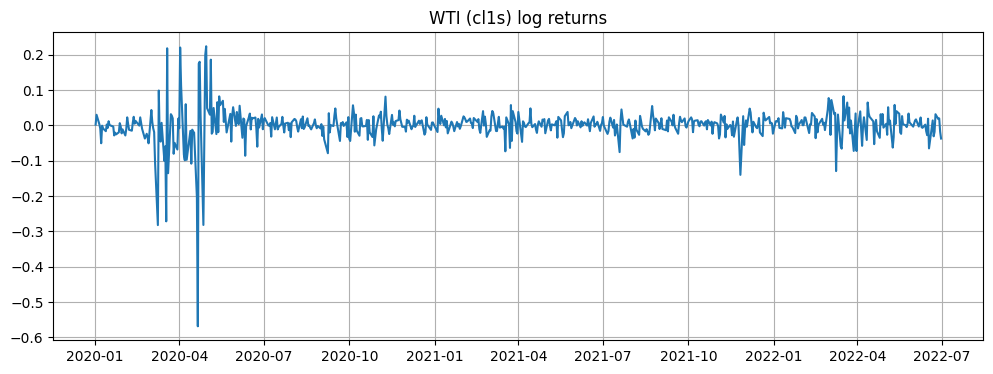

In [ ]:
plt.figure(figsize=(12, 4))
plt.plot(wti.index, wti['logret_1d'])
plt.title('WTI log returns')
plt.grid(True)
plt.show()

### 3.1 Base features (what you had + extras)
<p> In this section we are extracting the extra base cols for wti </p>


In [8]:
base_cols = [
    'logret_1d', 'ret_5d', 'ret_10d', 'ret_20d', 'ret_60d',
    'vol_20d', 'vol_60d', 'parkinson_20d', 'garman_klass_20d',
    'vol_of_vol_20d', 'vol_ratio_5_60',
    'volume_z_20d', 'oi_z_60d', 'oi_change_5d', 'volume_oi_ratio',
    'rsi_14', 'macd', 'macd_signal', 'macd_hist',
    'bb_width_20', 'bb_pos_20', 'atr_14', 'adx_14',
    'dd_from_60d_high', 'runup_from_60d_low', 'days_since_60d_high',
    'trend_tstat_10', 'trend_tstat_20', 'trend_tstat_60',
    'trend_tstat_best', 'trend_H_best',
]
wti[base_cols].tail()

,logret_1d,ret_5d,ret_10d,ret_20d,ret_60d,vol_20d,vol_60d,parkinson_20d,garman_klass_20d,vol_of_vol_20d,...,atr_14,adx_14,dd_from_60d_high,runup_from_60d_low,days_since_60d_high,trend_tstat_10,trend_tstat_20,trend_tstat_60,trend_tstat_best,trend_H_best
date,,,,,,,,,,,,,,,,,,,,,
2022-06-24,0.031623,-0.068497,-0.098684,-0.002163,0.080100,0.023483,0.030097,0.028119,0.030228,0.005444,...,1.664778,17.061100,-0.098423,0.197721,11.0,-6.877725,-2.156899,11.497975,11.497975,60.0
2022-06-27,0.017957,0.014525,-0.073790,-0.017718,0.064290,0.022550,0.029876,0.028263,0.030553,0.005139,...,1.660974,16.780195,-0.082087,0.219423,12.0,-4.056940,-2.833680,11.904422,11.904422,60.0
2022-06-28,0.019790,0.020247,-0.056152,-0.006481,0.156577,0.022935,0.028362,0.028291,0.030544,0.004800,...,1.604082,15.995568,-0.063740,0.243796,13.0,-1.885477,-3.159060,11.692984,11.692984,60.0
2022-06-29,-0.017875,0.033248,-0.057351,-0.020874,0.148824,0.023263,0.028438,0.028096,0.030183,0.004407,...,1.602051,14.973078,-0.080328,0.221760,14.0,-0.903275,-3.886410,11.174834,11.174834,60.0
2022-06-30,-0.037306,0.014189,-0.067012,-0.063312,0.071918,0.024568,0.028470,0.028625,0.030443,0.004102,...,1.612281,14.845878,-0.114005,0.177021,15.0,-0.818599,-5.141227,10.425742,10.425742,60.0


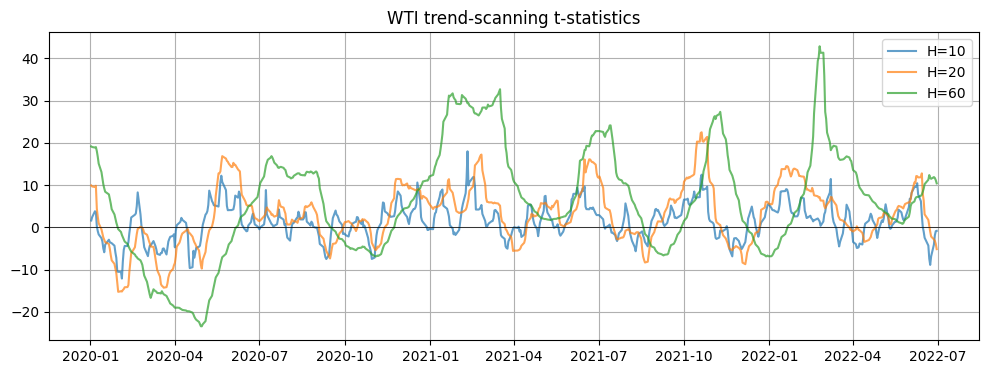

In [46]:
# Trend scanning t-stats — Lecture 1, max-|t| over multiple horizons
fig, ax = plt.subplots(figsize=(12, 4))
for h in [10, 20, 60]:
    ax.plot(wti.index, wti[f'trend_tstat_{h}'], label=f'H={h}', alpha=0.7)
ax.axhline(0, color='k', lw=0.5)
ax.set_title('WTI trend-scanning t-statistics')
ax.legend()
ax.grid(True)
plt.show()

## 4. Energy-specific features (Tier 2a)
<p> Explaining the energy features in this section </p>

Meta-labeling uses a secondary model to decide to act on a primary model's signal. The features below give that secondary model regime, sector, fundamental, and seasonal context.

---

### Basket Features
| Feature | Role |
|---|---|
| `energy_basket_ret_5d` | Sector-wide 5-day momentum. WTI moving *with* the basket confirms the signal; moving *against* it suggests idiosyncratic noise, so apply more skepticism. |
| `energy_basket_vol_20d` | Regime volatility. High vol degrades primary model accuracy, so the meta-model should reduce confidence or abstain. |

---

### Relative & Correlation Features
| Feature | Role |
|---|---|
| `rel_ret_vs_basket_5d` | WTI return minus basket return. Captures whether WTI is leading or lagging the complex, useful for spotting dislocations or momentum confirmation. |
| `corr_to_basket_60d` | Structural regime. High corr means WTI is driven by sector-level macro. Low corr means WTI is trading on its own supply-side drivers (Cushing, shale), so sector features carry less weight. |

---

### Crack Spread Features
| Feature | Role |
|---|---|
| `crack_321_proxy` | 3-2-1 refining margin. Wide crack signals robust physical demand and confirms bullish signals. |
| `crack_321_z_60d` | Z-score of the crack over 60 days. Normalises across market environments; extreme readings point to regime shifts in demand. |
| `ho_cl_spread` | Heating oil crack leg. Proxy for distillate and industrial demand, strongest as a signal in winter months. |
| `rb_cl_spread` | Gasoline crack leg. Proxy for consumer driving demand, strongest during driving season (May to Sep). |

---

### Seasonal & Calendar Features
| Feature | Role |
|---|---|
| `month_sin`, `month_cos` | Cyclical month encoding that avoids the Dec/Jan discontinuity and preserves circular calendar structure. Captures refinery turnaround cycles and seasonal demand patterns. |
| `dow_sin`, `dow_cos` | Cyclical day-of-week encoding. Wednesday is EIA report day (highest information content, highest noise); Friday te

## 4. Energy-specific features (Tier 2a)
<p> Explaining the energy features in this section </p>

Meta-labeling uses a secondary model to decide to act on a primary model's signal. The features below give that secondary model regime, sector, fundamental, and seasonal context.

---

### Basket Features
| Feature | Role |
|---|---|
| `energy_basket_ret_5d` | Sector-wide 5-day momentum. WTI moving *with* the basket confirms the signal; moving *against* it suggests idiosyncratic noise, so apply more skepticism. |
| `energy_basket_vol_20d` | Regime volatility. High vol degrades primary model accuracy, so the meta-model should reduce confidence or abstain. |

---

### Relative & Correlation Features
| Feature | Role |
|---|---|
| `rel_ret_vs_basket_5d` | WTI return minus basket return. Captures whether WTI is leading or lagging the complex, useful for spotting dislocations or momentum confirmation. |
| `corr_to_basket_60d` | Structural regime. High corr means WTI is driven by sector-level macro. Low corr means WTI is trading on its own supply-side drivers (Cushing, shale), so sector features carry less weight. |

---

### Crack Spread Features
| Feature | Role |
|---|---|
| `crack_321_proxy` | 3-2-1 refining margin. Wide crack signals robust physical demand and confirms bullish signals. |
| `crack_321_z_60d` | Z-score of the crack over 60 days. Normalises across market environments; extreme readings point to regime shifts in demand. |
| `ho_cl_spread` | Heating oil crack leg. Proxy for distillate and industrial demand, strongest as a signal in winter months. |
| `rb_cl_spread` | Gasoline crack leg. Proxy for consumer driving demand, strongest during driving season (May to Sep). |

---

### Seasonal & Calendar Features
| Feature | Role |
|---|---|
| `month_sin`, `month_cos` | Cyclical month encoding that avoids the Dec/Jan discontinuity and preserves circular calendar structure. Captures refinery turnaround cycles and seasonal demand patterns. |
| `dow_sin`, `dow_cos` | Cyclical day-of-week encoding. Wednesday is EIA report day (highest information content, highest noise); Friday te

In [10]:
energy_cols = [
    'energy_basket_ret_5d', 'energy_basket_vol_20d',
    'rel_ret_vs_basket_5d', 'corr_to_basket_60d',
    'crack_321_proxy', 'crack_321_z_60d',
    'ho_cl_spread', 'rb_cl_spread',
    'month_sin', 'month_cos', 'dow_sin', 'dow_cos',
    'winter_indicator', 'driving_season',
]
wti[energy_cols].tail()

,energy_basket_ret_5d,energy_basket_vol_20d,rel_ret_vs_basket_5d,corr_to_basket_60d,crack_321_proxy,crack_321_z_60d,ho_cl_spread,rb_cl_spread,month_sin,month_cos,dow_sin,dow_cos,winter_indicator,driving_season
date,,,,,,,,,,,,,,
2022-06-24,-0.076530,0.031862,0.008033,0.783091,-0.007808,-0.653094,-2.152614,-1.151036,1.224647e-16,-1.0,-0.951057,0.309017,0.0,1.0
2022-06-27,-0.014179,0.032228,0.028704,0.776613,-0.035379,-2.143010,-2.200607,-1.180108,1.224647e-16,-1.0,0.000000,1.000000,0.0,1.0
2022-06-28,-0.001454,0.032284,0.021700,0.768638,-0.001817,-0.235772,-2.221490,-1.172391,1.224647e-16,-1.0,0.951057,0.309017,0.0,1.0
2022-06-29,-0.025822,0.032777,0.059071,0.772642,-0.016514,-1.046729,-2.242871,-1.186471,1.224647e-16,-1.0,0.587785,-0.809017,0.0,1.0
2022-06-30,-0.065902,0.034846,0.080091,0.768077,-0.007818,-0.562919,-2.237879,-1.200694,1.224647e-16,-1.0,-0.587785,-0.809017,0.0,1.0


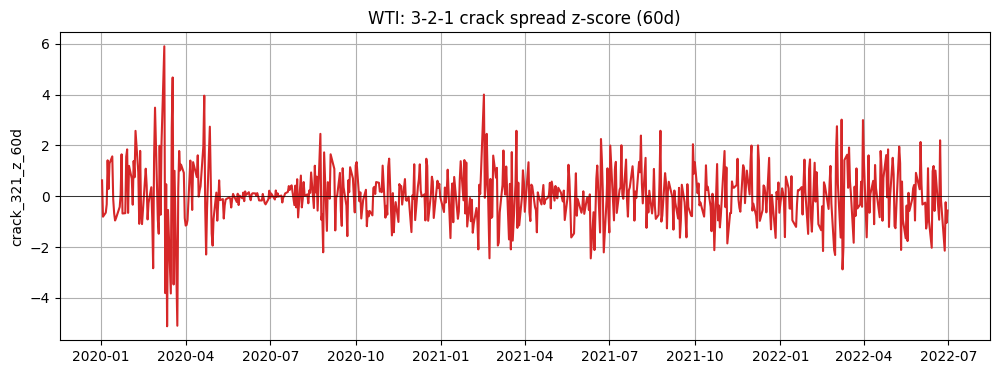

In [11]:
fig, ax1 = plt.subplots(figsize=(12, 4))
ax1.plot(wti.index, wti['crack_321_z_60d'], color='tab:red', label='crack 60d z')
ax1.axhline(0, color='k', lw=0.5)
ax1.set_ylabel('crack_321_z_60d')
ax1.set_title('WTI: 3-2-1 crack spread z-score (60d)')
ax1.grid(True)
plt.show()

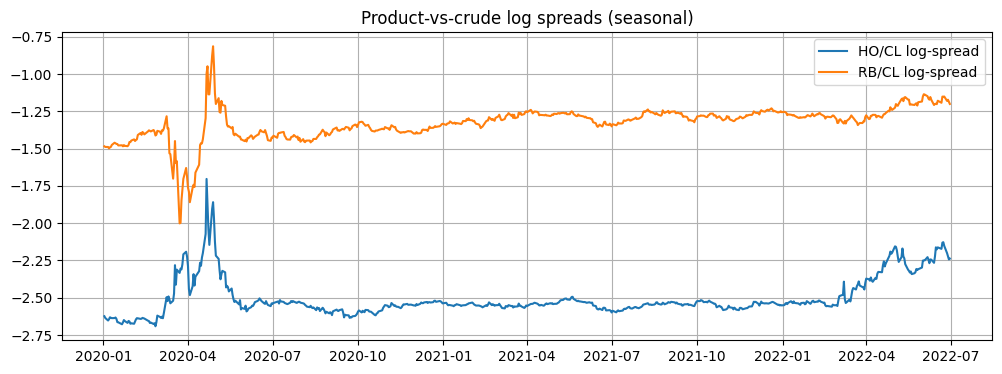

In [12]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(wti.index, wti['ho_cl_spread'], label='HO/CL log-spread')
ax.plot(wti.index, wti['rb_cl_spread'], label='RB/CL log-spread')
ax.set_title('Product-vs-crude log spreads (seasonal)')
ax.legend()
ax.grid(True)
plt.show()

### 4.1 OVX implied-volatility features

OVX is the CBOE Crude Oil Volatility Index, the implied-vol surface for USO options and the oil-market analogue of VIX. It is a forward-looking measure of expected WTI volatility, useful alongside the backward-looking `vol_20d`, `parkinson_20d`, and related features.

In this section we compute the following:
- `ovx_close` daily close
- `ovx_z` z-score on a 63-day window
- `iv_rv_ratio` implied vol (OVX) divided by realised vol (21-day annualised, in vol points)
- `ovx_slope` 5-day percentage change

### Why These Features Matter for Meta-Labeling

The core idea is that options markets price in information that price-based features miss. When OVX is elevated, the market is paying up for crash protection, which usually means someone knows something or at least fears something. That is exactly the regime where a trend-following primary signal is most likely to get whipsawed.

`ovx_close` gives the raw implied vol level. On its own it is noisy, but it tells the meta-model whether the market is broadly calm or stressed. A bullish WTI signal fired into a 50+ OVX reading deserves a lot more skepticism than the same signal at OVX 25.

`ovx_z` normalises that level against the past 63 days. An OVX of 35 is unremarkable in a high-vol year but extreme in a quiet one. The z-score is what actually tells the meta-model whether the market is unusually fearful relative to its recent baseline, which is the number that matters for confidence calibration.

`iv_rv_ratio` is the most informative of the four. When implied vol runs well above realised vol, options are expensive and the market is pricing in a jump that has not happened yet. That tends to mean either a real catalyst is coming or the market is being irrational. Either way, signal quality drops. When IV is below RV, options are cheap, the market has stopped hedging, and price action tends to be cleaner and more trend-friendly. The ratio is a direct read on how much the market trusts its own price signals.

`ovx_slope` captures whether fear is building or fading. A sharply rising OVX over 5 days, even from a moderate level, often precedes the kind of volatile, choppy price action that kills quantitative signals. A falling OVX after a spike is the opposite: the market is calming down and directional signals start working again. The slope gives the meta-model a sense of direction, not just level.


In [13]:
def load_ovx():
    """Return OVX close series indexed by date, or None if unavailable."""
    local = '../data/src/ovx.csv'
    df = pd.read_csv(local)
    date_col = 'Date' if 'Date' in df.columns else 'date'
    close_col = 'Close' if 'Close' in df.columns else 'close'
    df[date_col] = pd.to_datetime(df[date_col])
    return df.set_index(date_col)[close_col].rename('ovx_close').sort_index()


ovx_close = load_ovx()
if ovx_close is not None:
    ovx_close.index = pd.to_datetime(ovx_close.index).tz_localize(None)
    print('OVX rows:', len(ovx_close),
          'range:', ovx_close.index.min().date(), '→', ovx_close.index.max().date())
else:
    print('No OVX data available — subsequent OVX cells will be skipped.')

OVX rows: 4789 range: 2007-05-10 → 2026-05-21


In [14]:
if ovx_close is not None:
    ovx = ovx_close.to_frame()
    ovx['ovx_z'] = (
        (ovx['ovx_close'] - ovx['ovx_close'].rolling(63).mean())
        / ovx['ovx_close'].rolling(63).std()
    )
    ovx['ovx_slope'] = ovx['ovx_close'].pct_change(5)

    # iv_rv_ratio: implied (OVX, already in annualised vol points) over realised.
    # vol_20d is std of daily logret — annualise by sqrt(252) and ×100 for vol points.
    rv_pts = wti['vol_20d'] * np.sqrt(252) * 100
    ovx['iv_rv_ratio'] = ovx['ovx_close'] / rv_pts.reindex(ovx.index)

    wti = wti.join(ovx[['ovx_close', 'ovx_z', 'iv_rv_ratio', 'ovx_slope']], how='left')
    print(wti[['ovx_close', 'ovx_z', 'iv_rv_ratio', 'ovx_slope']].dropna().tail())
else:
    print('Skipped: OVX not loaded.')

            ovx_close     ovx_z  iv_rv_ratio  ovx_slope
date                                                   
2022-06-24  46.990002 -0.948578     1.260500   0.015561
2022-06-27  46.990002 -0.974712     1.312651  -0.044724
2022-06-28  46.590000 -1.102164     1.279671   0.000644
2022-06-29  48.570000 -0.590286     1.315257  -0.008573
2022-06-30  48.900002 -0.479887     1.253809   0.006587


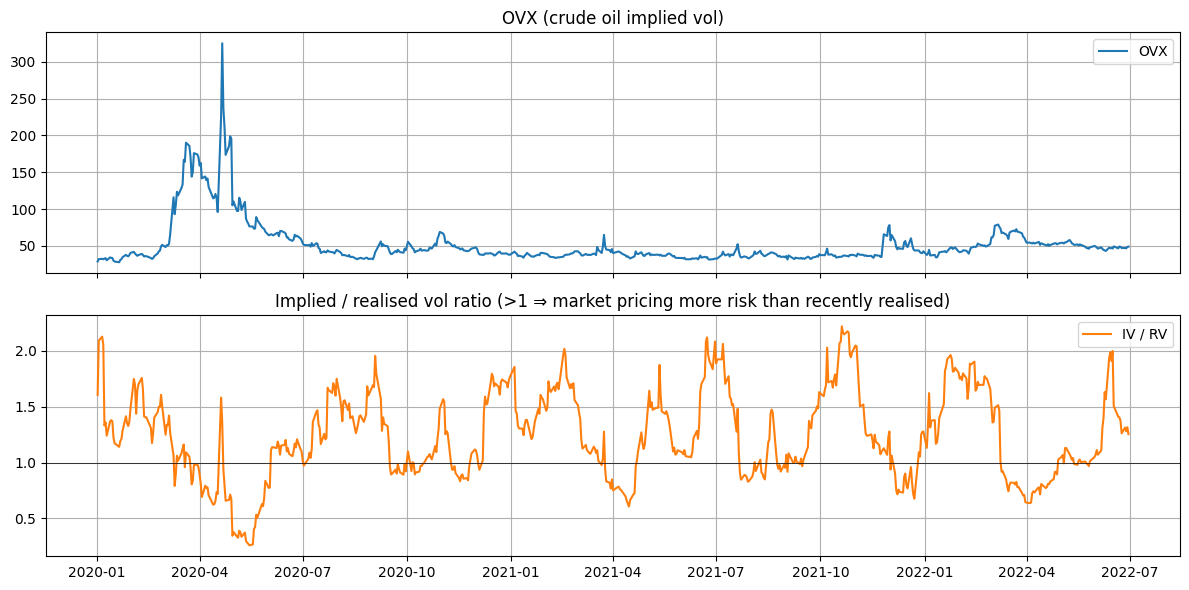

In [15]:
if 'ovx_close' in wti.columns and wti['ovx_close'].notna().any():
    fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
    axes[0].plot(wti.index, wti['ovx_close'], label='OVX')
    axes[0].set_title('OVX (crude oil implied vol)')
    axes[0].grid(True); axes[0].legend()
    axes[1].plot(wti.index, wti['iv_rv_ratio'], label='IV / RV', color='tab:orange')
    axes[1].axhline(1.0, color='k', lw=0.5)
    axes[1].set_title('Implied / realised vol ratio (>1 ⇒ market pricing more risk than recently realised)')
    axes[1].grid(True); axes[1].legend()
    plt.tight_layout()
    plt.show()

## 5. Latent / Hidden-State Features

**GMM — Lecture 2**: 3-component GMM on `[vol_20d, vol_of_vol_20d, parkinson_20d]`. Walk-forward refit every 63 trading days, 504-day warmup. Components are re-sorted by mean vol after every refit so `gmm_resp_low_vol` always means low-vol regardless of refit shuffling.

**HMM — Lecture 3**: 2-state Gaussian HMM (calm / turbulent) on `[logret_1d, vol_20d]`.
- Trained walk-forward (same schedule as the GMM).
- **Filtering, not smoothing** — we use the forward algorithm so `hmm_filt_*` at time `t` only depends on data up to `t`. Calling `predict_proba` on a fitted HMM runs forward-backward and uses future data within the training window; we don't do that.
- `hmm_next_turbulent = α_t @ Q` is a one-step-ahead forecast.
- `hmm_regime_age` is days since the hard regime last switched.
- Basket HMMs (`hmm_basket_turbulent_energy`, `hmm_basket_turbulent_metals`) run on cross-sectional mean return and vol of each asset class.

**K-means** K=3 on the cross-section `[ret_5d, vol_20d, volume_z_20d]` per asset class per day. `kmeans_cluster_size` is the fraction of instruments sharing the same cluster. 1.0 means all instruments in the asset class are co-moving; 0.25 means there is no correlation between instruments.

### Why These Features Matter for Meta-Labeling

The three models here are doing something the surface features cannot: they infer the *hidden state* the market is in rather than just describing what prices did. That distinction matters for meta-labeling because signal quality is not stationary. A momentum signal that works well in a calm, trending regime gets destroyed in a turbulent one. These features give the meta-model a probabilistic read on which world it is operating in.

**GMM** fits a mixture of three Gaussians on vol, vol-of-vol, and Parkinson vol. The result is a soft assignment: each day gets a probability of belonging to each of the three volatility regimes rather than a hard label. The meta-model can then learn that a bullish WTI signal fired on a day where `gmm_resp_high_vol` is 0.8 has a very different hit rate than the same signal on a day where `gmm_resp_low_vol` dominates. The walk-forward refit is important here: a static GMM would let future vol regimes bleed into past regime assignments, which is a subtle form of lookahead bias that is easy to miss.

**HMM** adds temporal structure that GMM ignores. Markets do not jump randomly between vol regimes: they tend to persist in a state for days or weeks before transitioning. The HMM captures that stickiness through a transition matrix, so `hmm_filt_turbulent` at time *t* is not just a function of today's vol but of the entire path of returns and vol up to today. The filtering constraint is critical: using the forward algorithm only means we never condition on data we would not have had in live trading. `hmm_next_turbulent` is a one-step-ahead regime forecast, which is the most actionable output: the meta-model can use it to pre-emptively reduce confidence before a turbulent period begins rather than reacting after the fact. `hmm_regime_age` adds something neither the GMM nor the raw HMM probability captures: how long we have been in the current state. Fresh regime transitions tend to be noisy and uncertain; a regime that has persisted for 20 days is more settled and primary signals tend to be more reliable within it.

The basket HMMs run the same logic at the sector level. A WTI signal fired when the energy basket HMM is already in a turbulent state has a very different risk profile than one fired when the basket is calm, even if WTI's own vol looks manageable on that particular day.

**K-means** is asking a different question entirely: not what vol regime the market is in, but how *coherent* the asset class is right now. `kmeans_cluster_size` near 1.0 means all instruments in the asset class are behaving the same way, returns, vol, and volume are all moving together. That is the environment where a sector-level signal on WTI has the most backing: the whole complex is co-moving and a directional bet on crude is effectively a bet on the sector. When `kmeans_cluster_size` is low, the asset class is fragmented. Some instruments are trending up, others down, volumes are dispersed. In that environment a WTI signal is much more likely to be idiosyncratic noise rather than a genuine sector move, and the meta-model should apply more skepticism.

In [38]:
latent_cols = [
    'gmm_resp_low_vol', 'gmm_resp_med_vol', 'gmm_resp_high_vol', 'gmm_max_resp',
    'hmm_filt_calm', 'hmm_filt_turbulent', 'hmm_next_turbulent', 'hmm_regime_age',
    'hmm_basket_turbulent_energy',
    'kmeans_cluster_id', 'kmeans_cluster_size',
]
wti[latent_cols].tail()

,gmm_resp_low_vol,gmm_resp_med_vol,gmm_resp_high_vol,gmm_max_resp,hmm_filt_calm,hmm_filt_turbulent,hmm_next_turbulent,hmm_regime_age,hmm_basket_turbulent_energy,kmeans_cluster_id,kmeans_cluster_size
date,,,,,,,,,,,
2022-06-24,0.915901,0.084099,2.174129e-08,0.0,0.977984,0.022016,0.027402,11.0,0.999921,1.0,0.50
2022-06-27,0.891821,0.108179,2.454488e-08,0.0,0.991398,0.008602,0.014437,12.0,0.999909,0.0,0.25
2022-06-28,0.933724,0.066276,1.484922e-08,0.0,0.992304,0.007696,0.013561,13.0,0.999930,0.0,0.25
2022-06-29,0.964947,0.035053,7.721195e-09,0.0,0.992119,0.007881,0.013740,14.0,0.999981,0.0,0.25
2022-06-30,0.974733,0.025267,5.975771e-09,0.0,0.946683,0.053317,0.057655,15.0,1.000000,2.0,0.50


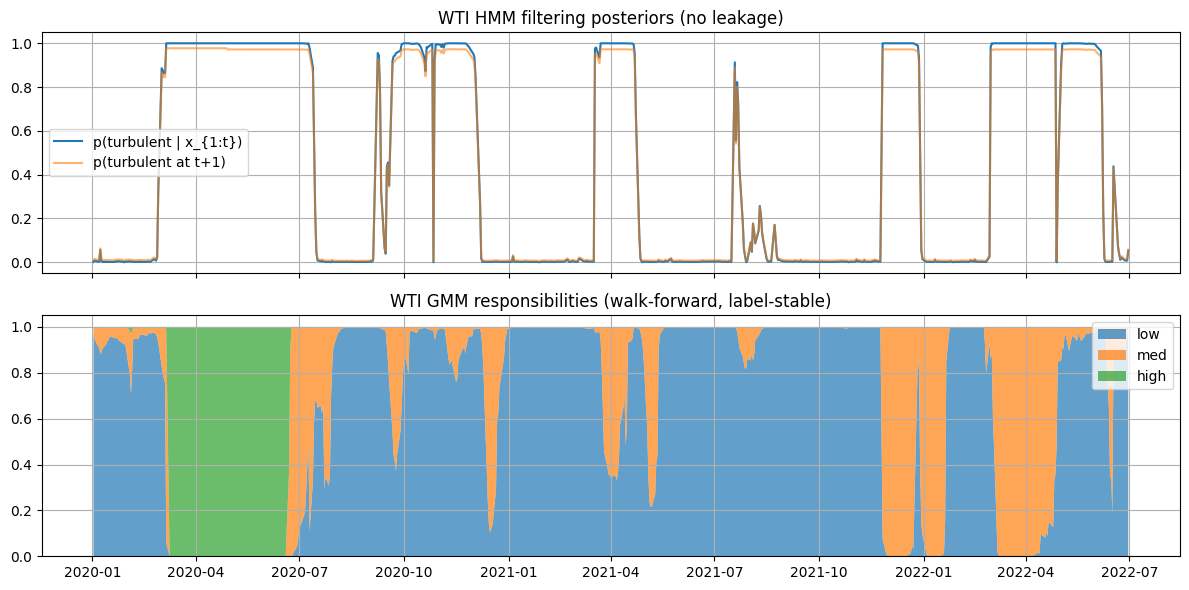

In [39]:
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
axes[0].plot(wti.index, wti['hmm_filt_turbulent'], label='p(turbulent | x_{1:t})')
axes[0].plot(wti.index, wti['hmm_next_turbulent'], label='p(turbulent at t+1)', alpha=0.6)
axes[0].set_title('WTI HMM filtering posteriors (no leakage)')
axes[0].legend(); axes[0].grid(True)

axes[1].stackplot(wti.index,
                  wti['gmm_resp_low_vol'].fillna(0),
                  wti['gmm_resp_med_vol'].fillna(0),
                  wti['gmm_resp_high_vol'].fillna(0),
                  labels=['low', 'med', 'high'], alpha=0.7)
axes[1].set_title('WTI GMM responsibilities (walk-forward, label-stable)')
axes[1].legend(loc='upper right'); axes[1].grid(True)
plt.tight_layout()
plt.show()

## 6. Primary signal features

In [40]:
sig_cols = [
    'primary_signal',
    'primary_signal_lag1', 'primary_signal_lag5',
    'primary_signal_streak', 'primary_signal_agreement_5d',
]
wti[sig_cols].dropna().head(10)

,primary_signal,primary_signal_lag1,primary_signal_lag5,primary_signal_streak,primary_signal_agreement_5d
date,,,,,
2020-01-09,-1.0,-1.0,0.0,1.0,0.0
2020-01-10,-1.0,-1.0,1.0,2.0,-0.4
2020-01-13,1.0,-1.0,1.0,0.0,-0.4
2020-01-14,0.0,1.0,0.0,1.0,-0.4
2020-01-15,1.0,0.0,-1.0,2.0,0.0
2020-01-16,-1.0,1.0,-1.0,0.0,0.0
2020-01-17,1.0,-1.0,-1.0,0.0,0.4
2020-01-21,-1.0,1.0,0.0,0.0,0.2
2020-01-22,-1.0,-1.0,1.0,1.0,-0.2


In this section we address the downstream steps. StandardScaler, PCA, HMM-on-PCs, and triple-barrier are unchanged in spirit; the only differences are:

1. **Bigger input**: 73 candidate features rather than 8.
2. **Walk-forward refits**: PCA is refit on a rolling basis for better clustering stability across regimes.
3. **Filtering vs smoothing**: Features going into the meta-model use the forward-only `hmm_filt_*` columns already produced, or a custom forward pass, to avoid lookahead bias.

### Why This Pipeline Is Set Up This Way

The three changes are not cosmetic. Each one is a direct response to a real failure mode that would quietly break the meta-model in live trading.

**Scaling before PCA** is non-negotiable when features have different units. OVX lives around 30 to 60, crack spreads are in dollars per barrel, and GMM responsibilities are probabilities between 0 and 1. Without StandardScaler, PCA would just find directions that explain variance in whichever feature happens to have the largest numeric range. After scaling, every feature gets an equal shot at influencing the principal components.

**PCA on 73 features** is doing something more important than compression. Many of the 73 features are correlated by construction: `ovx_z` and `ovx_close` move together, `hmm_filt_turbulent` and `gmm_resp_high_vol` are both vol-regime signals, the crack spread legs overlap with the 3-2-1. Feeding correlated features directly into a downstream model inflates their effective weight and destabilises coefficient estimates. PCA rotates the feature space into orthogonal directions ordered by variance explained, so the HMM and meta-model see a cleaner, lower-dimensional representation with no redundancy baked in.

**Walk-forward PCA refits** matter because the covariance structure of energy markets shifts over time. The first principal component in a low-vol 2017 sample is not the same linear combination of features as the first PC in a stress period like 2020. A static PCA fit on the full history lets future covariance structure influence how past data is projected, which is a form of lookahead bias that is easy to overlook. Refitting every 63 days on an expanding window means each day's PC scores are computed from a rotation matrix that only saw data available at that point in time.

**Filtering over smoothing** is the most important constraint in the whole pipeline. The forward-backward algorithm that standard HMM implementations use for `predict_proba` is a smoother: the probability assigned to time *t* depends on observations both before and after *t*. That is fine for offline analysis but fatal for a trading model, since it means today's regime label was partly determined by tomorrow's returns. Using the forward algorithm only means `hmm_filt_turbulent` at time *t* is a genuine real-time estimate, exactly what the model would have produced had it been running live. The discipline here is what makes the backtest credible.

In [19]:
SIGNAL_START = '2021-08-16'

# Pick the feature set you want to feed the downstream HMM.
# Start with the base + energy domain set; you can extend with latent/signal cols.
downstream_cols = [
    'logret_1d', 'vol_20d', 'vol_60d', 'parkinson_20d',
    'ret_5d', 'ret_20d', 'ret_60d',
    'rsi_14', 'macd_hist', 'bb_pos_20', 'adx_14',
    'dd_from_60d_high', 'trend_tstat_best',
    'crack_321_z_60d', 'ho_cl_spread', 'rb_cl_spread',
    'rel_ret_vs_basket_5d', 'corr_to_basket_60d',
    'winter_indicator', 'driving_season',
]

# Add OVX columns if they were loaded in §4.1
ovx_cols = [c for c in ['ovx_z', 'iv_rv_ratio', 'ovx_slope'] if c in wti.columns]
if ovx_cols:
    downstream_cols += ovx_cols
    print('Including OVX features:', ovx_cols)

X = wti[downstream_cols].dropna()

X_train = X.loc[X.index <  SIGNAL_START]
X_test  = X.loc[X.index >= SIGNAL_START]

print('train:', X_train.shape, 'test:', X_test.shape)

Including OVX features: ['ovx_z', 'iv_rv_ratio', 'ovx_slope']
train: (408, 23) test: (221, 23)


In [20]:
scaler = StandardScaler()
X_train_wti = scaler.fit_transform(X_train)
X_test_wti  = scaler.transform(X_test)

pca = PCA(n_components=0.95, random_state=42)
X_train_pca = pca.fit_transform(X_train_wti)
X_test_pca  = pca.transform(X_test_wti)

pc_cols = [f'PC{i+1}' for i in range(X_train_pca.shape[1])]
train_pca_df = pd.DataFrame(X_train_pca, index=X_train.index, columns=pc_cols)
test_pca_df  = pd.DataFrame(X_test_pca,  index=X_test.index,  columns=pc_cols)

var = pd.DataFrame({
    'PC': pc_cols,
    'ratio': pca.explained_variance_ratio_,
    'cumulative': np.cumsum(pca.explained_variance_ratio_),
})
print('PCs kept:', pca.n_components_)

      PC     ratio  cumulative
0    PC1  0.326066    0.326066
1    PC2  0.207193    0.533260
2    PC3  0.095890    0.629149
3    PC4  0.073990    0.703139
4    PC5  0.054261    0.757400
5    PC6  0.043594    0.800995
6    PC7  0.035767    0.836761
7    PC8  0.031155    0.867916
8    PC9  0.027737    0.895653
9   PC10  0.022117    0.917771
10  PC11  0.019643    0.937413
11  PC12  0.016746    0.954159
PCs kept: 12


In [21]:
# Using a BIC Sweep for the most optimal number of clusters but it is capped at 5

def hmm_bic(model, X):
    K = model.n_components
    T, d = X.shape
    logL = model.score(X)
    k_params = (K - 1) + K * (K - 1) + K * (2 * d)
    return -2 * logL + k_params * np.log(T), logL

best = {'bic': np.inf, 'hmm': None, 'K': None}
for K in range(2, 6):
    best_for_K = {'bic': np.inf, 'hmm': None}
    for seed in range(10):
        h = GaussianHMM(n_components=K, covariance_type='diag',
                        n_iter=1000, random_state=42 + seed)
        try:
            h.fit(X_train_pca)
            bic, _ = hmm_bic(h, X_train_pca)
            if bic < best_for_K['bic']:
                best_for_K = {'bic': bic, 'hmm': h}
        except Exception:
            continue
    print(f'K={K}: BIC={best_for_K["bic"]:,.1f}')
    if best_for_K['bic'] < best['bic']:
        best = {'bic': best_for_K['bic'], 'hmm': best_for_K['hmm'], 'K': K}

print('Chosen K =', best['K'])

K=2: BIC=13,330.3
K=3: BIC=12,517.2
K=4: BIC=11,797.0
K=5: BIC=11,406.9
Chosen K = 5


In [22]:
# IMPORTANT: predict_proba runs forward-backward (smoothing) which uses future
# data inside the train window. For meta-model features we want filtering only.
# Below: filtering posteriors via the forward algorithm.

def hmm_filter(model, X):
    """Forward-only filtering posterior - no future leakage."""
    T = len(X)
    K = model.n_components
    log_alpha = np.empty((T, K))
    # initial
    log_alpha[0] = np.log(model.startprob_ + 1e-300) + model._compute_log_likelihood(X[:1])[0]
    log_trans = np.log(model.transmat_ + 1e-300)
    log_obs = model._compute_log_likelihood(X)
    for t in range(1, T):
        # log_alpha[t,k] = logsumexp_j(log_alpha[t-1,j] + log_trans[j,k]) + log_obs[t,k]
        m = log_alpha[t-1, :, None] + log_trans   # (K, K)
        log_alpha[t] = log_obs[t] + (m.max(axis=0) +
                                     np.log(np.exp(m - m.max(axis=0)).sum(axis=0)))
    # normalise to get posteriors
    log_alpha -= log_alpha.max(axis=1, keepdims=True)
    a = np.exp(log_alpha)
    return a / a.sum(axis=1, keepdims=True)

train_post = hmm_filter(best['hmm'], X_train_pca)
test_post  = hmm_filter(best['hmm'], X_test_pca)

for i in range(best['K']):
    train_pca_df[f'hmm_filt_{i}'] = train_post[:, i]
    test_pca_df[f'hmm_filt_{i}']  = test_post[:, i]

train_pca_df.head()

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12,hmm_filt_0,hmm_filt_1,hmm_filt_2,hmm_filt_3,hmm_filt_4
date,,,,,,,,,,,,,,,,,
2020-01-02,-2.096601,-1.186972,-1.174715,0.618764,-0.440979,0.901281,-0.666800,0.298036,-0.256651,0.489074,-0.190366,-0.071212,1.145499e-192,5.343758e-308,1.000000,3.740472e-308,5.750010e-117
2020-01-03,-2.655322,-1.118488,-1.567996,0.704416,1.039034,1.473609,-0.991641,0.574943,0.368395,1.011276,0.904494,-0.334950,5.980362e-102,4.189991e-124,1.000000,3.740149e-269,2.706141e-07
2020-01-06,-2.638915,-1.217244,-1.547761,0.886247,0.675750,1.584834,-0.950277,0.557223,0.425064,0.868373,1.077376,-0.175029,1.836097e-21,3.572211e-14,1.000000,9.896377e-139,1.360338e-07
2020-01-07,-2.283379,-1.425496,-1.476913,0.846235,0.283681,1.546606,-0.845504,0.409301,0.265265,0.791120,0.828527,-0.037980,4.129626e-21,4.688554e-15,1.000000,1.740149e-26,3.306388e-07
2020-01-08,-0.586201,-2.023961,-0.840305,0.163840,-1.545250,0.735803,-0.596834,0.422323,0.184833,-0.007430,-0.530413,0.393602,2.330199e-16,4.449585e-12,0.320784,2.596462e-19,6.792157e-01


### 7.1 Triple-barrier meta-labels
<p>
In this section we are generating the labels for the meta model based on the primary signal additionally we are using the at average true range calculated in our feature engineering pipeline, we opted for the 14 day average true range because it is a widely used technical indicator that measures financial assets volatility over the last 14 candles. 
</p>

In [23]:
def get_daily_vol(close, span=20):
    log_ret = np.log(close).diff()
    return log_ret.ewm(span=span).std()

def triple_barrier_meta_labels(close, signals, pt_sl, max_hold):
    vol = get_daily_vol(close)
    out = []
    for t0, side in signals.items():
        if pd.isna(side) or side == 0:
            continue
        if t0 not in close.index or t0 not in vol.index:
            continue
        sigma = vol.loc[t0]
        if pd.isna(sigma) or sigma <= 0:
            continue
        pt =  pt_sl[0] * sigma
        sl = -pt_sl[1] * sigma
        idx = close.index.searchsorted(t0)
        t1 = close.index[min(idx + max_hold, len(close.index) - 1)]
        entry = close.loc[t0]
        future = close.loc[t0:t1].iloc[1:]
        if future.empty:
            continue
        ret = (future / entry - 1) * side
        hit_pt = ret[ret >= pt].index.min()
        hit_sl = ret[ret <= sl].index.min()
        cand = {k: v for k, v in {'pt': hit_pt, 'sl': hit_sl, 't1': t1}.items()
                if pd.notna(v)}
        first = min(cand, key=cand.get)
        out.append({
            'entry': t0, 'exit': cand[first],
            'sigma_at_entry': sigma, 'primary_signal': side,
            'first_touch': first,
            'meta_label': 1 if first == 'pt' else 0,
        })
    return pd.DataFrame(out).set_index('entry')

# Use raw close from the OHLCV file (the parquet drops it on save)
ohlcv = pd.read_csv('../data/src/ohlcv_data.csv')
ohlcv['date'] = pd.to_datetime(ohlcv['date'])
wti_close = (
    ohlcv[ohlcv['instrument'] == 'cl1s']
    .set_index('date')['close']
    .sort_index()
)

wti_signals = wti['primary_signal'].dropna()
wti_labels = triple_barrier_meta_labels(wti_close, wti_signals, pt_sl=[1.5, 1.5], max_hold=20)
print('labels:', len(wti_labels), 'win rate:', wti_labels['meta_label'].mean().round(3))
wti_labels.head()

labels: 382 win rate: 0.463


,exit,sigma_at_entry,primary_signal,first_touch,meta_label
entry,,,,,
2020-01-03,2020-01-08,0.013842,1.0,sl,0
2020-01-06,2020-01-08,0.013170,1.0,sl,0
2020-01-08,2020-01-22,0.020437,-1.0,pt,1
2020-01-09,2020-01-15,0.019443,-1.0,pt,1
2020-01-10,2020-01-22,0.018609,-1.0,pt,1


In [24]:
# Align X with labels — same pattern as your notebook
y_train = wti_labels.loc[wti_labels.index <  SIGNAL_START, 'meta_label']
y_test  = wti_labels.loc[wti_labels.index >= SIGNAL_START, 'meta_label']

X_train_wti = train_pca_df.reindex(y_train.index).dropna()
X_test_wti  = test_pca_df.reindex(y_test.index).dropna()
y_train = y_train.loc[X_train_wti.index]
y_test  = y_test.loc[X_test_wti.index]

print(X_train_wti.shape, y_train.shape)
print(X_test_wti.shape,  y_test.shape)

(248, 17) (248,)
(134, 17) (134,)


<h3> WTI model </h3>
<p> In this section we will be building the different meta models using logistic regression, randomforest, xgbboost, and neural networks and we will run different tests to ensure we obtain the best one in sample. <p>

In [25]:
N_SPLITS = 5

def walk_forward_cv_auc(model, X, y, n_splits=N_SPLITS):
    tscv = TimeSeriesSplit(n_splits=n_splits)
    fold_aucs = []
    for train_idx, test_idx in tscv.split(X.values):
        X_tr, X_te = X.values[train_idx], X.values[test_idx]
        y_tr, y_te = y.values[train_idx], y.values[test_idx]
        if len(np.unique(y_te)) < 2:
            continue
        model.fit(X_tr, y_tr)
        proba = model.predict_proba(X_te)[:, 1]
        fold_aucs.append(roc_auc_score(y_te, proba))
    return {'fold_aucs': fold_aucs, 'mean_auc': np.mean(fold_aucs), 'std_auc': np.std(fold_aucs)}


In [26]:
# In this section we are developing the logistic regression parameter grid

lr_param_grid = [
    {'C': 0.01,  'penalty': 'l2', 'class_weight': None,       'solver': 'lbfgs',     'max_iter': 1000},
    {'C': 0.1,   'penalty': 'l2', 'class_weight': None,       'solver': 'lbfgs',     'max_iter': 1000},
    {'C': 1.0,   'penalty': 'l2', 'class_weight': None,       'solver': 'lbfgs',     'max_iter': 1000},
    {'C': 10.0,  'penalty': 'l2', 'class_weight': None,       'solver': 'lbfgs',     'max_iter': 1000},
    {'C': 0.1,   'penalty': 'l1', 'class_weight': None,       'solver': 'liblinear', 'max_iter': 1000},
    {'C': 1.0,   'penalty': 'l1', 'class_weight': None,       'solver': 'liblinear', 'max_iter': 1000},
    {'C': 0.1,   'penalty': 'l2', 'class_weight': 'balanced', 'solver': 'lbfgs',     'max_iter': 1000},
    {'C': 1.0,   'penalty': 'l2', 'class_weight': 'balanced', 'solver': 'lbfgs',     'max_iter': 1000},
]

lr_results = []
for params in lr_param_grid:
    pipe = Pipeline([('scaler', StandardScaler()), ('clf', LogisticRegression(**params))])
    cv = walk_forward_cv_auc(pipe, X_train_wti, y_train)
    lr_results.append({**params, **cv})

lr_df = pd.DataFrame(lr_results).sort_values('mean_auc', ascending=False)
print(lr_df[['C', 'penalty', 'class_weight', 'mean_auc', 'std_auc']].to_string(index=False))
best_lr_params = lr_df.iloc[0][['C', 'penalty', 'class_weight', 'solver', 'max_iter']].to_dict()

    C penalty class_weight  mean_auc  std_auc
 0.10      l2         None  0.535383 0.056244
 0.10      l2     balanced  0.535376 0.056598
 1.00      l2         None  0.526868 0.060707
 1.00      l2     balanced  0.526861 0.061411
10.00      l2         None  0.526266 0.060631
 0.01      l2         None  0.525154 0.054563
 1.00      l1         None  0.507924 0.091727
 0.10      l1         None  0.483224 0.071433


In [27]:
# -----------------------------------------------------------------------
# Random Forest
# max_depth      : shallow (3-5) = less overfit. None = fully grown.
# min_samples_leaf: higher = smoother, more regularised splits.
# max_features   : features per split. lower = more diverse trees.
# -----------------------------------------------------------------------
rf_param_grid = [
    {'n_estimators': 100, 'max_depth': 3,    'min_samples_leaf': 5,  'max_features': 'sqrt', 'class_weight': None},
    {'n_estimators': 100, 'max_depth': 5,    'min_samples_leaf': 5,  'max_features': 'sqrt', 'class_weight': None},
    {'n_estimators': 100, 'max_depth': 8,    'min_samples_leaf': 5,  'max_features': 'sqrt', 'class_weight': None},
    {'n_estimators': 200, 'max_depth': 5,    'min_samples_leaf': 10, 'max_features': 'sqrt', 'class_weight': None},
    {'n_estimators': 200, 'max_depth': 8,    'min_samples_leaf': 10, 'max_features': 'sqrt', 'class_weight': None},
    {'n_estimators': 200, 'max_depth': 1, 'min_samples_leaf': 20, 'max_features': 'sqrt', 'class_weight': None},
    {'n_estimators': 200, 'max_depth': 5,    'min_samples_leaf': 5,  'max_features': 0.5,    'class_weight': None},
    {'n_estimators': 200, 'max_depth': 5,    'min_samples_leaf': 10, 'max_features': 'sqrt', 'class_weight': 'balanced'},
]

rf_results = []
for params in rf_param_grid:
    model = RandomForestClassifier(**params, random_state=42, n_jobs=-1)
    cv = walk_forward_cv_auc(model, X_train_wti, y_train)
    rf_results.append({**params, **cv})

rf_df = pd.DataFrame(rf_results).sort_values('mean_auc', ascending=False)
print(rf_df[['n_estimators', 'max_depth', 'min_samples_leaf', 'mean_auc', 'std_auc']].to_string(index=False))
best_rf_params = rf_df.iloc[0][['n_estimators', 'max_depth', 'min_samples_leaf', 'max_features', 'class_weight']].to_dict()

 n_estimators  max_depth  min_samples_leaf  mean_auc  std_auc
          200          5                 5  0.513265 0.075367
          200          5                10  0.509351 0.067109
          200          8                10  0.509351 0.067109
          200          5                10  0.506216 0.070772
          200          1                20  0.503067 0.104068
          100          3                 5  0.484243 0.082753
          100          5                 5  0.465932 0.081855
          100          8                 5  0.458535 0.094498


In [28]:
# In this section is the XGB boost model we will be trying multiple different parameters and try to obtain the best one.
# -----------------------------------------------------------------------
# XGBoost
# learning_rate  : smaller = more rounds needed but better generalisation.
# max_depth      : 3-5 is usually optimal for financial data.
# subsample      : fraction of rows per tree. <1.0 reduces overfit.
# colsample_bytree: fraction of features per tree. same idea.
# scale_pos_weight: n_neg/n_pos. compensates for class imbalance.
# -----------------------------------------------------------------------
n_pos = int(y_train.sum())
n_neg = len(y_train) - n_pos
spw = n_neg / n_pos
print(f'scale_pos_weight = {spw:.2f}  (n_neg={n_neg}, n_pos={n_pos})')

xgb_param_grid = [
    {'n_estimators': 100, 'learning_rate': 0.05, 'max_depth': 3, 'subsample': 0.8, 'colsample_bytree': 0.8, 'scale_pos_weight': 1.0},
    {'n_estimators': 200, 'learning_rate': 0.05, 'max_depth': 3, 'subsample': 0.8, 'colsample_bytree': 0.8, 'scale_pos_weight': 1.0},
    {'n_estimators': 100, 'learning_rate': 0.05, 'max_depth': 5, 'subsample': 0.8, 'colsample_bytree': 0.8, 'scale_pos_weight': 1.0},
    {'n_estimators': 200, 'learning_rate': 0.05, 'max_depth': 5, 'subsample': 0.8, 'colsample_bytree': 0.8, 'scale_pos_weight': 1.0},
    {'n_estimators': 100, 'learning_rate': 0.1,  'max_depth': 3, 'subsample': 0.8, 'colsample_bytree': 0.8, 'scale_pos_weight': 1.0},
    {'n_estimators': 100, 'learning_rate': 0.1,  'max_depth': 5, 'subsample': 0.7, 'colsample_bytree': 0.7, 'scale_pos_weight': 1.0},
    {'n_estimators': 200, 'learning_rate': 0.05, 'max_depth': 3, 'subsample': 0.8, 'colsample_bytree': 0.8, 'scale_pos_weight': spw},
    {'n_estimators': 200, 'learning_rate': 0.05, 'max_depth': 5, 'subsample': 0.8, 'colsample_bytree': 0.8, 'scale_pos_weight': spw},
]

xgb_results = []
for params in xgb_param_grid:
    model = xgb.XGBClassifier(**params, eval_metric='logloss', random_state=42, verbosity=0)
    cv = walk_forward_cv_auc(model, X_train_wti, y_train)
    xgb_results.append({**params, **cv})

xgb_df = pd.DataFrame(xgb_results).sort_values('mean_auc', ascending=False)
print(xgb_df[['n_estimators', 'learning_rate', 'max_depth', 'subsample', 'scale_pos_weight', 'mean_auc', 'std_auc']].to_string(index=False))
best_xgb_params = xgb_df.iloc[0][['n_estimators', 'learning_rate', 'max_depth', 'subsample', 'colsample_bytree', 'scale_pos_weight']].to_dict()

scale_pos_weight = 1.16  (n_neg=133, n_pos=115)
 n_estimators  learning_rate  max_depth  subsample  scale_pos_weight  mean_auc  std_auc
          100           0.10          5        0.7          1.000000  0.565751 0.037162
          100           0.10          3        0.8          1.000000  0.552127 0.071212
          200           0.05          3        0.8          1.156522  0.546705 0.064888
          200           0.05          5        0.8          1.156522  0.541311 0.074517
          200           0.05          3        0.8          1.000000  0.529917 0.069984
          200           0.05          5        0.8          1.000000  0.524946 0.071759
          100           0.05          5        0.8          1.000000  0.502808 0.102472
          100           0.05          3        0.8          1.000000  0.497492 0.094450


In [29]:
# -----------------------------------------------------------------------
# Summary: retrain best of each on full X_train, evaluate once on X_test
# -----------------------------------------------------------------------
best_lr  = Pipeline([('scaler', StandardScaler()), ('clf', LogisticRegression(**best_lr_params))])
best_rf  = RandomForestClassifier(**best_rf_params, random_state=42, n_jobs=-1)
best_xgb = xgb.XGBClassifier(**best_xgb_params, eval_metric='logloss', random_state=42, verbosity=0)

for name, model in [('LR', best_lr), ('RF', best_rf), ('XGB', best_xgb)]:
    model.fit(X_train_wti, y_train)
    proba = model.predict_proba(X_test_wti)[:, 1]
    print(f'{name}  test AUC: {roc_auc_score(y_test, proba):.4f}')

LR  test AUC: 0.5764
RF  test AUC: 0.5556
XGB  test AUC: 0.4758


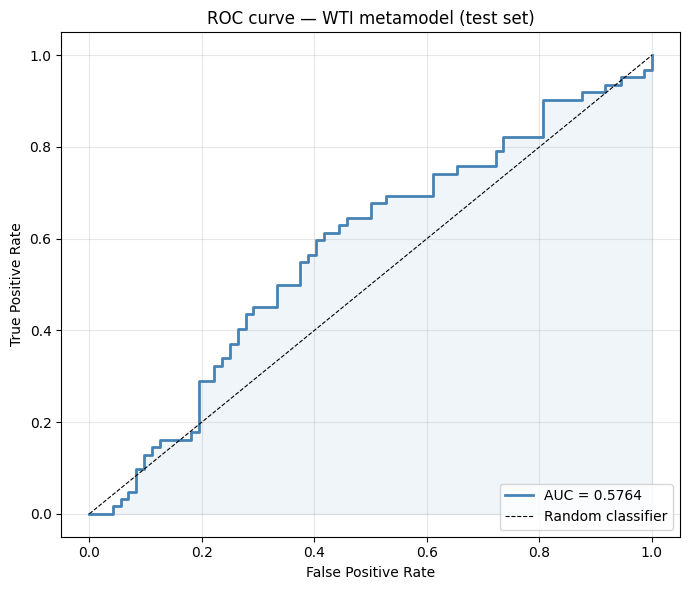

Test AUC: 0.5764


In [30]:

best_model = best_lr  # swap to best_lr or best_rf if needed

proba = best_model.predict_proba(X_test_wti)[:, 1]
fpr, tpr, _ = roc_curve(y_test, proba)
auc = roc_auc_score(y_test, proba)

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(fpr, tpr, color='steelblue', lw=2, label=f'AUC = {auc:.4f}')
ax.fill_between(fpr, tpr, alpha=0.08, color='steelblue')
ax.plot([0, 1], [0, 1], 'k--', lw=0.8, label='Random classifier')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC curve — WTI metamodel (test set)')

ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f'Test AUC: {auc:.4f}')

In [31]:
scaler_nn = StandardScaler()
X_tr_sc = scaler_nn.fit_transform(X_train_wti.values).astype(np.float32)
X_te_sc = scaler_nn.transform(X_test_wti.values).astype(np.float32)
input_dim = X_tr_sc.shape[1]

y_tr = y_train.values.astype(np.float32)
y_te = y_test.values.astype(np.float32)

# pos_weight for class imbalance: same logic as XGB scale_pos_weight
n_pos = y_tr.sum()
n_neg = len(y_tr) - n_pos
pos_weight = n_neg / max(n_pos, 1)
print(f'input_dim={input_dim}, pos_weight={pos_weight:.2f}')


input_dim=17, pos_weight=1.16


In [32]:
# In this section of the code we will be running the neural networks

# -----------------------------------------------------------------------
# Walk-forward CV helper for Keras models
# model_fn: a callable that returns a freshly compiled Keras model
# X, y: numpy arrays already scaled
# -----------------------------------------------------------------------
def walk_forward_cv_keras(model_fn, X, y, n_splits=N_SPLITS,
                           epochs=80, batch_size=32, patience=10):
    tscv = TimeSeriesSplit(n_splits=n_splits)
    fold_aucs = []

    for fold, (train_idx, val_idx) in enumerate(tscv.split(X)):
        X_f, X_v = X[train_idx], X[val_idx]
        y_f, y_v = y[train_idx], y[val_idx]

        if len(np.unique(y_v)) < 2:
            continue

        model = model_fn()

        early_stop = keras.callbacks.EarlyStopping(
            monitor='val_auc',
            patience=patience,
            mode='max',
            restore_best_weights=True,
        )

        model.fit(
            X_f, y_f,
            validation_data=(X_v, y_v),
            epochs=epochs,
            batch_size=batch_size,
            callbacks=[early_stop],
            verbose=0,
            class_weight={0: pos_weight, 1: 1.0},
        )

        proba = model.predict(X_v, verbose=0).flatten()
        fold_aucs.append(roc_auc_score(y_v, proba))

    return {
        'fold_aucs': fold_aucs,
        'mean_auc':  float(np.mean(fold_aucs)),
        'std_auc':   float(np.std(fold_aucs)),
    }

In [33]:
# -----------------------------------------------------------------------
# Walk-forward CV helper for Keras models
# model_fn: a callable that returns a freshly compiled Keras model
# X, y: numpy arrays already scaled
# -----------------------------------------------------------------------
def walk_forward_cv_keras(model_fn, X, y, n_splits=N_SPLITS,
                           epochs=80, batch_size=32, patience=10):
    tscv = TimeSeriesSplit(n_splits=n_splits)
    fold_aucs = []

    for fold, (train_idx, val_idx) in enumerate(tscv.split(X)):
        X_f, X_v = X[train_idx], X[val_idx]
        y_f, y_v = y[train_idx], y[val_idx]

        if len(np.unique(y_v)) < 2:
            continue

        model = model_fn()

        early_stop = keras.callbacks.EarlyStopping(
            monitor='val_auc',
            patience=patience,
            mode='max',
            restore_best_weights=True,
        )

        model.fit(
            X_f, y_f,
            validation_data=(X_v, y_v),
            epochs=epochs,
            batch_size=batch_size,
            callbacks=[early_stop],
            verbose=0,
            class_weight={0: pos_weight, 1: 1.0},
        )

        proba = model.predict(X_v, verbose=0).flatten()
        fold_aucs.append(roc_auc_score(y_v, proba))

    return {
        'fold_aucs': fold_aucs,
        'mean_auc':  float(np.mean(fold_aucs)),
        'std_auc':   float(np.std(fold_aucs)),
    }

In [41]:
# -----------------------------------------------------------------------
# Model 1: Feedforward Network (MLP)
#
# Params tuned:
#   hidden_dim : width of each hidden layer
#   dropout    : fraction of neurons dropped during training
#   lr         : Adam learning rate
# -----------------------------------------------------------------------
def make_mlp(hidden_dim=64, dropout=0.3, lr=1e-3):
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(hidden_dim, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(dropout),
        layers.Dense(hidden_dim // 2, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(dropout),
        layers.Dense(1, activation='sigmoid'),
    ])
    model.compile(
        optimizer=keras.optimizers.Adam(lr),
        loss='binary_crossentropy',
        metrics=[keras.metrics.AUC(name='auc')],
    )
    return model


mlp_param_grid = [
    {'hidden_dim': 32,  'dropout': 0.2, 'lr': 1e-3},
    {'hidden_dim': 64,  'dropout': 0.2, 'lr': 1e-3},
    {'hidden_dim': 64,  'dropout': 0.3, 'lr': 1e-3},
    {'hidden_dim': 128, 'dropout': 0.3, 'lr': 1e-3},
    {'hidden_dim': 64,  'dropout': 0.4, 'lr': 5e-4},
    {'hidden_dim': 128, 'dropout': 0.4, 'lr': 5e-4},
]

mlp_results = []
for params in mlp_param_grid:
    fn = lambda p=params: make_mlp(**p)
    cv = walk_forward_cv_keras(fn, X_tr_sc, y_tr)
    mlp_results.append({**params, **cv})
    print(f"hidden={params['hidden_dim']} dropout={params['dropout']} lr={params['lr']}  "
          f"mean_auc={cv['mean_auc']:.4f} std={cv['std_auc']:.4f}")
mlp_df = pd.DataFrame(mlp_results).sort_values('mean_auc', ascending=False)
best_mlp_params = {
    'hidden_dim': int(mlp_df.iloc[0]['hidden_dim']),
    'dropout':    float(mlp_df.iloc[0]['dropout']),
    'lr':         float(mlp_df.iloc[0]['lr']),
}
print('\nBest MLP:', best_mlp_params)

hidden=32 dropout=0.2 lr=0.001  mean_auc=0.5641 std=0.1258
hidden=64 dropout=0.2 lr=0.001  mean_auc=0.6320 std=0.0571
hidden=64 dropout=0.3 lr=0.001  mean_auc=0.5421 std=0.0885
hidden=128 dropout=0.3 lr=0.001  mean_auc=0.5407 std=0.0927
hidden=64 dropout=0.4 lr=0.0005  mean_auc=0.5702 std=0.1066
hidden=128 dropout=0.4 lr=0.0005  mean_auc=0.5447 std=0.0930

Best MLP: {'hidden_dim': 64, 'dropout': 0.2, 'lr': 0.001}


In [42]:
# -----------------------------------------------------------------------
# Model 2: Variable Selection Network (VSN)
#
# Learns a soft attention weight per feature so the network suppresses
# irrelevant features dynamically. Useful when you have ~70 features
# from different tiers where relevance shifts across regimes.
#
# How it works:
#   - A dense layer produces one weight per feature, softmaxed to sum to 1
#   - Each feature is individually transformed by its own small dense layer
#   - The weighted sum of transformed features feeds the classifier
# -----------------------------------------------------------------------
def make_vsn(hidden_dim=64, dropout=0.3, lr=1e-3):
    inputs = keras.Input(shape=(input_dim,))

    # Feature selection weights: one scalar per input feature
    selection_weights = layers.Dense(input_dim, activation='softmax',
                                     name='feature_weights')(inputs)

    # Per-feature transform: expand each scalar feature to hidden_dim
    # Then weight and sum across features
    expanded = layers.Reshape((input_dim, 1))(inputs)
    transformed = layers.Conv1D(
        filters=hidden_dim, kernel_size=1,
        activation='relu', name='feature_transform'
    )(expanded)                                          # (batch, input_dim, hidden_dim)

    # Apply selection weights: broadcast weights over hidden_dim
    weights_expanded = layers.Reshape((input_dim, 1))(selection_weights)
    weighted = layers.Multiply()([transformed, weights_expanded])
    combined = layers.Lambda(lambda x: tf.reduce_sum(x, axis=1))(weighted)  # (batch, hidden_dim)

    # Classifier head
    x = layers.BatchNormalization()(combined)
    x = layers.Dropout(dropout)(x)
    x = layers.Dense(hidden_dim // 2, activation='relu')(x)
    x = layers.Dropout(dropout)(x)
    outputs = layers.Dense(1, activation='sigmoid')(x)

    model = keras.Model(inputs, outputs)
    model.compile(
        optimizer=keras.optimizers.Adam(lr),
        loss='binary_crossentropy',
        metrics=[keras.metrics.AUC(name='auc')],
    )
    return model


vsn_param_grid = [
    {'hidden_dim': 32,  'dropout': 0.2, 'lr': 1e-3},
    {'hidden_dim': 64,  'dropout': 0.2, 'lr': 1e-3},
    {'hidden_dim': 64,  'dropout': 0.3, 'lr': 1e-3},
    {'hidden_dim': 128, 'dropout': 0.3, 'lr': 5e-4},
    {'hidden_dim': 64,  'dropout': 0.4, 'lr': 5e-4},
]

vsn_results = []
for params in vsn_param_grid:
    fn = lambda p=params: make_vsn(**p)
    cv = walk_forward_cv_keras(fn, X_tr_sc, y_tr)
    vsn_results.append({**params, **cv})
    print(f"hidden={params['hidden_dim']} dropout={params['dropout']} lr={params['lr']}  "
          f"mean_auc={cv['mean_auc']:.4f} std={cv['std_auc']:.4f}")

vsn_df = pd.DataFrame(vsn_results).sort_values('mean_auc', ascending=False)
best_vsn_params = {
    'hidden_dim': int(vsn_df.iloc[0]['hidden_dim']),
    'dropout':    float(vsn_df.iloc[0]['dropout']),
    'lr':         float(vsn_df.iloc[0]['lr']),
}
print('\nBest VSN:', best_vsn_params)

hidden=32 dropout=0.2 lr=0.001  mean_auc=0.5325 std=0.0822
hidden=64 dropout=0.2 lr=0.001  mean_auc=0.5664 std=0.1244
hidden=64 dropout=0.3 lr=0.001  mean_auc=0.5170 std=0.0869
hidden=128 dropout=0.3 lr=0.0005  mean_auc=0.5012 std=0.0582
hidden=64 dropout=0.4 lr=0.0005  mean_auc=0.5491 std=0.0931

Best VSN: {'hidden_dim': 64, 'dropout': 0.2, 'lr': 0.001}


In [43]:
# -----------------------------------------------------------------------
# Model 3: LSTM
#
# Builds a sequence of the last seq_len days before each trade entry.
# The LSTM sees the temporal pattern leading into the trade, not just
# the point-in-time snapshot.
#
# Params tuned:
#   seq_len    : how many past days to look back
#   hidden_dim : LSTM hidden state size
#   num_layers : stacked LSTM depth
#   dropout    : applied between layers and before output head
# -----------------------------------------------------------------------
def build_sequences(X_df, y_series, seq_len):
    """
    For each label date, extract seq_len rows ending strictly before
    that date. Returns X_seq (N, seq_len, features) and y_arr (N,).
    """
    X_arr = X_df.values.astype(np.float32)
    dates = X_df.index
    X_seqs, y_out, valid_dates = [], [], []

    for entry_date, label in y_series.items():
        if entry_date not in dates:
            continue
        pos = dates.get_loc(entry_date)
        if pos < seq_len:
            continue
        X_seqs.append(X_arr[pos - seq_len : pos])
        y_out.append(label)
        valid_dates.append(entry_date)

    return (np.array(X_seqs, dtype=np.float32),
            np.array(y_out, dtype=np.float32),
            valid_dates)


def make_lstm(seq_len, hidden_dim=64, num_layers=2, dropout=0.3, lr=1e-3):
    model = keras.Sequential()
    model.add(layers.Input(shape=(seq_len, input_dim)))
    for i in range(num_layers):
        return_seq = (i < num_layers - 1)  # all layers except the last return sequences
        model.add(layers.LSTM(hidden_dim, return_sequences=return_seq, dropout=dropout))
    model.add(layers.Dropout(dropout))
    model.add(layers.Dense(hidden_dim // 2, activation='relu'))
    model.add(layers.Dense(1, activation='sigmoid'))
    model.compile(
        optimizer=keras.optimizers.Adam(lr),
        loss='binary_crossentropy',
        metrics=[keras.metrics.AUC(name='auc')],
    )
    return model


# Build the full scaled feature matrix for sequence extraction
train_cutoff = X_train_wti.index.max()
full_X_sc = pd.DataFrame(
    scaler_nn.transform(pd.concat([X_train_wti, X_test_wti]).values),
    index=pd.concat([X_train_wti, X_test_wti]).index,
    columns=X_train_wti.columns,
)

lstm_param_grid = [
    {'seq_len': 10, 'hidden_dim': 32, 'num_layers': 1, 'dropout': 0.2, 'lr': 1e-3},
    {'seq_len': 10, 'hidden_dim': 64, 'num_layers': 2, 'dropout': 0.3, 'lr': 1e-3},
    {'seq_len': 20, 'hidden_dim': 32, 'num_layers': 1, 'dropout': 0.2, 'lr': 1e-3},
    {'seq_len': 20, 'hidden_dim': 64, 'num_layers': 2, 'dropout': 0.3, 'lr': 1e-3},
    {'seq_len': 20, 'hidden_dim': 64, 'num_layers': 2, 'dropout': 0.4, 'lr': 5e-4},
    {'seq_len': 60, 'hidden_dim': 64, 'num_layers': 2, 'dropout': 0.3, 'lr': 5e-4},
]

lstm_results = []
for params in lstm_param_grid:
    seq_len = params['seq_len']
    X_seq, y_seq, seq_dates = build_sequences(
        full_X_sc.loc[:train_cutoff], y_train, seq_len
    )
    if len(X_seq) == 0:
        continue

    tscv_seq = TimeSeriesSplit(n_splits=N_SPLITS)
    fold_aucs = []
    for train_idx, val_idx in tscv_seq.split(X_seq):
        X_f, X_v = X_seq[train_idx], X_seq[val_idx]
        y_f, y_v = y_seq[train_idx], y_seq[val_idx]
        if len(np.unique(y_v)) < 2:
            continue

        model = make_lstm(**params)
        early_stop = keras.callbacks.EarlyStopping(
            monitor='val_auc', patience=10, mode='max', restore_best_weights=True
        )
        model.fit(
            X_f, y_f,
            validation_data=(X_v, y_v),
            epochs=80, batch_size=32,
            callbacks=[early_stop],
            verbose=0,
            class_weight={0: pos_weight, 1: 1.0},
        )
        proba = model.predict(X_v, verbose=0).flatten()
        fold_aucs.append(roc_auc_score(y_v, proba))

    lstm_results.append({**params, 'mean_auc': np.mean(fold_aucs), 'std_auc': np.std(fold_aucs)})
    print(f"seq={params['seq_len']} hidden={params['hidden_dim']} layers={params['num_layers']}  "
          f"mean_auc={lstm_results[-1]['mean_auc']:.4f} std={lstm_results[-1]['std_auc']:.4f}")

lstm_df = pd.DataFrame(lstm_results).sort_values('mean_auc', ascending=False)
best_lstm_params = {
    'seq_len':    int(lstm_df.iloc[0]['seq_len']),
    'hidden_dim': int(lstm_df.iloc[0]['hidden_dim']),
    'num_layers': int(lstm_df.iloc[0]['num_layers']),
    'dropout':    float(lstm_df.iloc[0]['dropout']),
    'lr':         float(lstm_df.iloc[0]['lr']),
}
print('\nBest LSTM:', best_lstm_params)


seq=10 hidden=32 layers=1  mean_auc=0.6480 std=0.0623
seq=10 hidden=64 layers=2  mean_auc=0.5988 std=0.0463
seq=20 hidden=32 layers=1  mean_auc=0.5622 std=0.0921
seq=20 hidden=64 layers=2  mean_auc=0.5360 std=0.0538
seq=20 hidden=64 layers=2  mean_auc=0.5755 std=0.0692
seq=60 hidden=64 layers=2  mean_auc=0.5313 std=0.1519

Best LSTM: {'seq_len': 10, 'hidden_dim': 32, 'num_layers': 1, 'dropout': 0.2, 'lr': 0.001}


In [44]:
# MLP
final_mlp = make_mlp(**best_mlp_params)
final_mlp.fit(X_tr_sc, y_tr, epochs=150, batch_size=32, verbose=0,
              class_weight={0: pos_weight, 1: 1.0})
mlp_proba = final_mlp.predict(X_te_sc, verbose=0).flatten()
print(f'MLP  test AUC: {roc_auc_score(y_te, mlp_proba):.4f}')

# VSN
final_vsn = make_vsn(**best_vsn_params)
final_vsn.fit(X_tr_sc, y_tr, epochs=150, batch_size=32, verbose=0,
              class_weight={0: pos_weight, 1: 1.0})
vsn_proba = final_vsn.predict(X_te_sc, verbose=0).flatten()
print(f'VSN  test AUC: {roc_auc_score(y_te, vsn_proba):.4f}')

# LSTM
seq_len = int(best_lstm_params['seq_len'])
X_seq_tr, y_seq_tr, _ = build_sequences(full_X_sc.loc[:train_cutoff], y_train, seq_len)
X_seq_te, y_seq_te, _ = build_sequences(full_X_sc, y_test, seq_len)

final_lstm = make_lstm(**{k: v for k, v in best_lstm_params.items()
                          if k in ['seq_len', 'hidden_dim', 'num_layers', 'dropout', 'lr']})
final_lstm.fit(X_seq_tr, y_seq_tr, epochs=150, batch_size=32, verbose=0,
               class_weight={0: pos_weight, 1: 1.0})
lstm_proba = final_lstm.predict(X_seq_te, verbose=0).flatten()
print(f'LSTM test AUC: {roc_auc_score(y_seq_te, lstm_proba):.4f}')

MLP  test AUC: 0.6624
VSN  test AUC: 0.5092
LSTM test AUC: 0.5437


In [47]:
# -----------------------------------------------------------------------
# Collect probabilities from all best models on test set
# -----------------------------------------------------------------------
model_probas = {
    'Logistic Regression': best_lr.predict_proba(X_test_wti)[:, 1],
    'Random Forest':       best_rf.predict_proba(X_test_wti)[:, 1],
    'XGBoost':             best_xgb.predict_proba(X_test_wti)[:, 1],
    'MLP':                 final_mlp.predict(X_te_sc, verbose=0).flatten(),
    'VSN':                 final_vsn.predict(X_te_sc, verbose=0).flatten(),
    'LSTM':                final_lstm.predict(
                               np.array([X_seq_te[i] for i in range(len(X_seq_te))],
                               dtype=np.float32), verbose=0).flatten(),
}

# y_te is the ground truth for all point-in-time models
# y_seq_te is ground truth for LSTM (fewer samples due to sequence building)
model_labels = {
    'Logistic Regression': y_te,
    'Random Forest':       y_te,
    'XGBoost':             y_te,
    'MLP':                 y_te,
    'VSN':                 y_te,
    'LSTM':                y_seq_te,
}

In [50]:
# -----------------------------------------------------------------------
# Threshold sweep for every model
# -----------------------------------------------------------------------
thresholds = np.arange(0.3, 0.81, 0.05)

all_results = {}
for model_name, proba in model_probas.items():
    y_true = model_labels[model_name]
    rows = []
    for t in thresholds:
        pred = (proba >= t).astype(int)
        n_trades = pred.sum()
        if n_trades == 0:
            continue
        rows.append({
            'threshold':  round(t, 2),
            'n_trades':   int(n_trades), # Total number of trades due to labeling
            'pct_taken':  round(100 * n_trades / len(pred), 1),
            'precision':  round(precision_score(y_true, pred, zero_division=0), 4), # The amount of trades taken
            'recall':     round(recall_score(y_true, pred, zero_division=0), 4),
            'f1':         round(f1_score(y_true, pred, zero_division=0), 4),
            'auc':        round(roc_auc_score(y_true, proba), 4),
        })
    all_results[model_name] = pd.DataFrame(rows)
    print(f'\n{model_name}')
    print(all_results[model_name].to_string(index=False))


Logistic Regression
 threshold  n_trades  pct_taken  precision  recall     f1    auc
      0.30       125       93.3     0.4640  0.9355 0.6203 0.5764
      0.35       122       91.0     0.4672  0.9194 0.6196 0.5764
      0.40       118       88.1     0.4746  0.9032 0.6222 0.5764
      0.45       104       77.6     0.4904  0.8226 0.6145 0.5764
      0.50        84       62.7     0.5119  0.6935 0.5890 0.5764
      0.55        71       53.0     0.5493  0.6290 0.5865 0.5764
      0.60        60       44.8     0.5500  0.5323 0.5410 0.5764
      0.65        44       32.8     0.5682  0.4032 0.4717 0.5764
      0.70        22       16.4     0.4545  0.1613 0.2381 0.5764
      0.75         8        6.0     0.3750  0.0484 0.0857 0.5764

Random Forest
 threshold  n_trades  pct_taken  precision  recall     f1    auc
      0.30       133       99.3     0.4662  1.0000 0.6359 0.5556
      0.35       128       95.5     0.4688  0.9677 0.6316 0.5556
      0.40       104       77.6     0.4808  0.8065 0.6

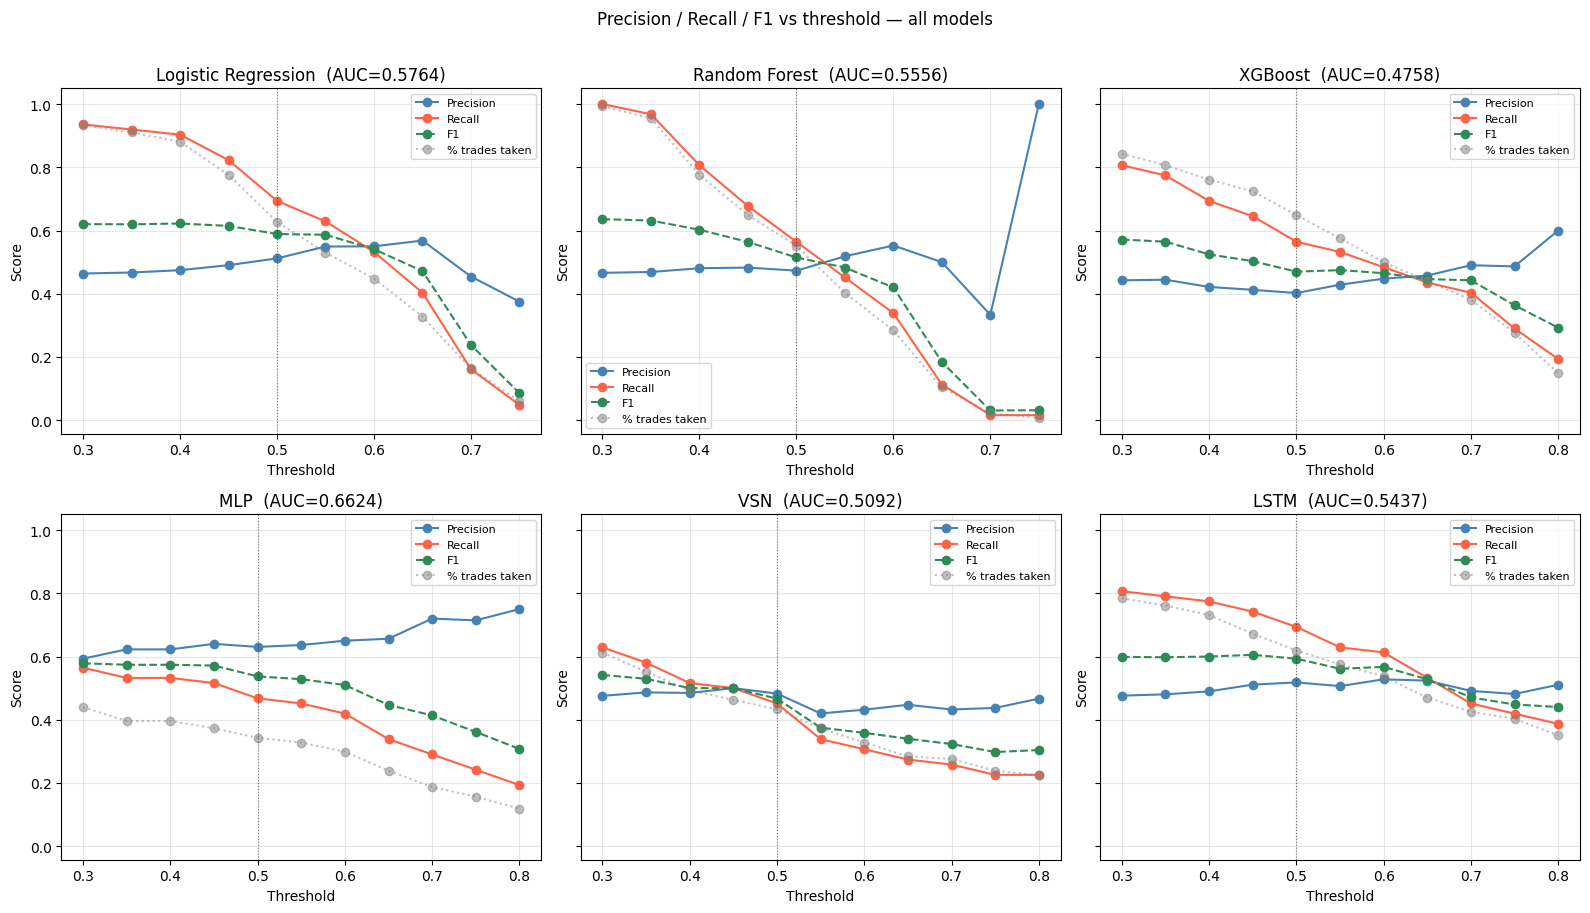

In [51]:
# -----------------------------------------------------------------------
# Plot precision and recall vs threshold for all models
# -----------------------------------------------------------------------
fig, axes = plt.subplots(2, 3, figsize=(16, 9), sharey=True)
axes = axes.flatten()

for ax, (model_name, df) in zip(axes, all_results.items()):
    ax.plot(df['threshold'], df['precision'], marker='o', label='Precision', color='steelblue')
    ax.plot(df['threshold'], df['recall'],    marker='o', label='Recall',    color='tomato')
    ax.plot(df['threshold'], df['f1'],        marker='o', label='F1',        color='seagreen', linestyle='--')
    ax.plot(df['threshold'], df['pct_taken'] / 100,
            marker='o', linestyle=':', alpha=0.5, color='gray', label='% trades taken')
    ax.axvline(0.5, color='black', lw=0.8, linestyle=':', alpha=0.5)
    ax.set_title(f'{model_name}  (AUC={df["auc"].iloc[0]:.4f})')
    ax.set_xlabel('Threshold')
    ax.set_ylabel('Score')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle('Precision / Recall / F1 vs threshold — all models', y=1.01)
plt.tight_layout()
plt.show()